# PythonLab3 Bootstrap and the stationary bootstrap

The following notebook contains a python implementation of the original R Lab on bootstrap by Argimiro Arratia @2023



##2. Libraries:
We will use the following libraries for the study along with their purpose:

In [4]:
# dcor for distance correlations
# recombinator for bootstrapping functions
!pip install dcor
!pip install recombinator
# numpy for computation
import numpy as np

# pandas for data management
import pandas as pd

# pyplot for plotting
import matplotlib.pyplot as plt

# statsmodels for statistical methods
import statsmodels.tsa.api as smt
from statsmodels.tsa.ar_model import AutoReg

# resampling for basic parametric bootstrap
from sklearn.utils import resample

import dcor as dcor
from recombinator.block_bootstrap import circular_block_bootstrap, stationary_bootstrap



Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 3.1 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.9/126.9 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.8/79.8 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.5/82.5 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 12.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.4 MB/s eta 0:00:00
  Created wheel for contexttimer: fil

## Basic Parametric Bootstrap

### Example 1
Bootstrap the mean of iid observations

In [5]:
# define the statistic for the mean:
def mean_boot(data, indices):
    return np.mean(data[indices])

# the iid data, and for the record compute (true) mean
x = np.random.exponential(scale=1/10, size=30)
true_mean = np.mean(x)

# bootstrap mean
n_resamples = 999
resample_indices = [resample(np.arange(x.shape[0])) for i in range(n_resamples)]
t_resamples = [mean_boot(x, indices) for indices in resample_indices]
mean_of_t_resamples = np.mean(t_resamples)

# original mean, bias: mean(t_resamples) - mean(x) & std error
print("Original mean:", true_mean)
print("Bootstrapped mean:", mean_of_t_resamples)
print("Bias:", mean_of_t_resamples - true_mean)
print("Standard error:", np.std(t_resamples, ddof=1))

Original mean: 0.09162123432369775
Bootstrapped mean: 0.09173668981922209
Bias: 0.0001154554955243442
Standard error: 0.02024749934997948


### Example 2
Significance of distance correlation (who's distribution is unknown)
the  bootstrap test is programmed in library energy as dcor.test originally in R, the dcor python library replicates the same implementation.

In [6]:
x = np.random.exponential(scale=1/10, size=30)
y = x**2
print(dcor.distance_correlation(x,y))

0.9541484017182036


Seems highly dependant. Let's see how significant is this.  
Distance covariance test: 
* Null: independent, if pvalue < alpha you can reject with that level alpha of confidence

In [7]:
dct = dcor.independence.distance_covariance_test(
    x,
    y,
    num_resamples=299,
)
print(dct.pvalue)

0.0033333333333333335


Let's consider other z possibly independent from x.

In [8]:
z = np.random.exponential(scale=1/3, size=30)
print(dcor.distance_correlation(z,x))

0.26418409454807107


And again test for significance.

In [9]:
dct2 = dcor.independence.distance_covariance_test(
    x,
    y,
    num_resamples=299,
)
print(dct.pvalue)

0.0033333333333333335


## Block Bootstrap

Example from Ch. 8.3 of Davison & Hinkley p 394.

<Axes: xlabel='Year'>

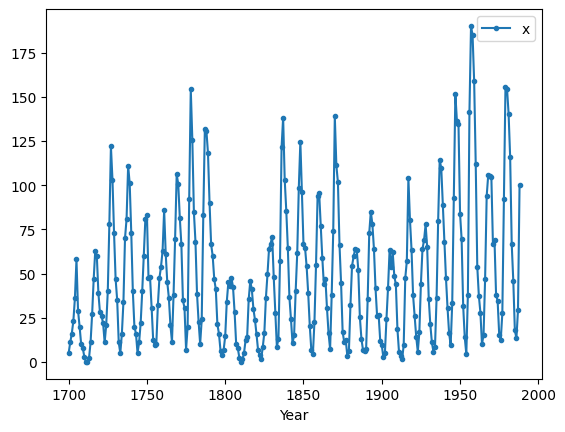

In [11]:
sunspot_year = pd.read_csv("sunspot.csv", sep=",", header=0, index_col=0)
sunspot_year["Year"] = pd.Series(range(1700,1989), index=sunspot_year.index)
sunspot_year.plot(x="Year", y="x", marker=".")

To stabilize the variance apply the following transformation to data


In [12]:
sun = pd.DataFrame(2*(np.sqrt(sunspot_year["x"]+1)-1))

<Axes: xlabel='Year'>

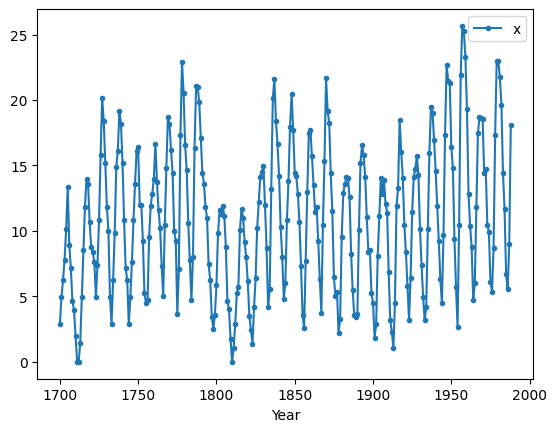

In [13]:
sun["Year"] = pd.Series(range(1700,1989), index=sunspot_year.index)
sun.plot(x="Year", y="x", marker=".")

Indexify the temporal variable.

In [14]:
sun['Year'] = pd.to_datetime(sun['Year'], format='%Y')
sun = sun.set_index('Year')

##Want to fit an AR(p). Check for autcorrelations to determine p.

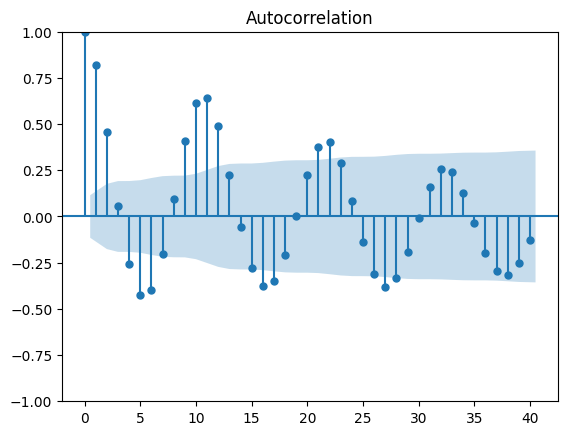

/usr/local/lib/python3.10/dist-packages/statsmodels/graphics/tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


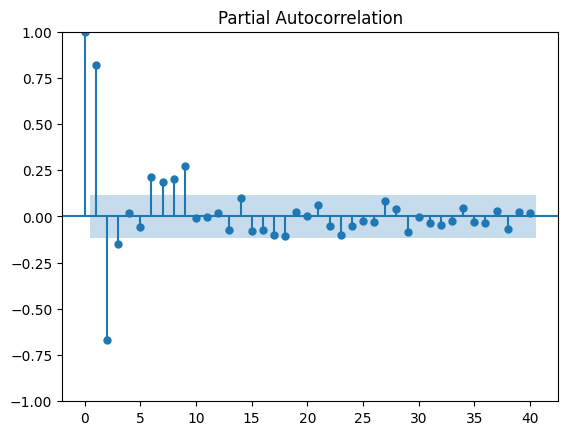

In [15]:
acf = smt.graphics.plot_acf(sun["x"], lags=40, alpha=0.05)
plt.show()

pacf = smt.graphics.plot_pacf(sun["x"], lags=40, alpha=0.05)
plt.show()

We seem to observe significance up to lag 9, we proceed to fit a model.

In [16]:
# fit an autoregressive model to the data
model = smt.AutoReg(sun, lags=9)
ar_fit = model.fit()
print("Fit of AR Model:", ar_fit.summary())

Fit of AR Model:                             AutoReg Model Results                             
Dep. Variable:                      x   No. Observations:                  289
Model:                     AutoReg(9)   Log Likelihood                -593.699
Method:               Conditional MLE   S.D. of innovations              2.017
Date:                Wed, 03 May 2023   AIC                           1209.399
Time:                        09:53:51   BIC                           1249.381
Sample:                    01-01-1709   HQIC                          1225.436
                         - 01-01-1988                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2978      0.513      2.532      0.011       0.293       2.303
x.L1           1.2256      0.058     21.295      0.000       1.113       1.338
x.L2          -0.4897      0.092   

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)


Now let's see how well is the computed order.  
To do so consider model-based simulations from AR(9) model. Bootstrap.

In [17]:
# HELP for the todo, a function to produce AR models up to order 25, outputing order, mean and the replicate series
def sun_fun(tsb):
    ar_fit = smt.AutoReg(sun, lags=25).fit()
    return [ar_fit.ar_lags, np.mean(tsb), tsb]

## Block resampling
We perform bootstrap simulations over the sun dataset using block resampling with lenght of the size of the square root of the number of rows in the sun dataset and 999 replications.

In [18]:
n=len(sun)
bootstrap_simulations = circular_block_bootstrap(sun, 
                               block_length=int(np.sqrt(n)), 
                               replications=999, 
                               replace=True)

In [19]:
bootstrap_simulations

array([[[11.56465997],
        [11.28156617],
        [11.92838828],
        ...,
        [ 4.92820323],
        [ 8.58300524],
        [11.85640646]],

       [[ 5.50999334],
        [ 3.58569602],
        [ 3.40370243],
        ...,
        [ 3.76194412],
        [10.42577965],
        [15.32050808]],

       [[14.        ],
        [13.62049935],
        [10.64911064],
        ...,
        [14.44384383],
        [14.18641406],
        [12.84587485]],

       ...,

       [[14.82854717],
        [18.69782597],
        [18.17919721],
        ...,
        [ 4.164414  ],
        [ 5.53657747],
        [13.2184099 ]],

       [[ 8.01998004],
        [16.31938864],
        [21.06512519],
        ...,
        [14.0623784 ],
        [12.58766602],
        [ 8.27618606]],

       [[11.11487705],
        [14.0623784 ],
        [12.80540442],
        ...,
        [ 1.84707681],
        [ 2.89897949],
        [ 8.07968253]]])

We plot on of our simulations against the original data. We observe that the obtained series differs significantly. Change the index and observe results for different simmulations.

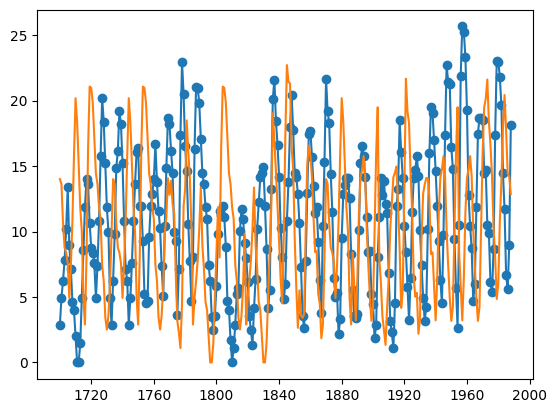

In [20]:
plt.plot(sun.index, sun, 'o-')
plt.plot(sun.index, bootstrap_simulations[2])

Now we provide some code to help obtain the maximum order by making estimates from the previous bootstrap.

In [21]:
estimates_from_bootstrap = []
ar_estimates_from_bootstrap = np.zeros((len(bootstrap_simulations), ))

for b in range(len(bootstrap_simulations)):
    y_bootstrap = bootstrap_simulations[b, :]
    ar_bootstrap = AutoReg(y_bootstrap, lags=25)
    estimate_from_bootstrap = ar_bootstrap.fit()
    estimates_from_bootstrap.append(estimate_from_bootstrap)
    ar_estimates_from_bootstrap[b] = estimate_from_bootstrap.params[1]
    # obtain the maximum order

Compare the bootstrap variance for a specific simulation against the original variance.

In [22]:
(bootstrap_simulations[2].var(), sun.var())

(30.116314069490603,
 x    32.056673
 dtype: float64)

Compare the bootstrap variance for all simulations against the original variance.

In [23]:
(bootstrap_simulations.var(), sun.var())

(31.95422158770497,
 x    32.056673
 dtype: float64)

Compute the mean for all simulations against the original mean.

In [24]:
(bootstrap_simulations.mean(), sun.mean())

(10.902343379799987,
 x    10.903807
 dtype: float64)

### Stationary bootstrap

We repeat the same procedure as before but this time performing stationary bootstrap instead of block resampling.

In [25]:
st_bootstrap_simulations = stationary_bootstrap(sun, 
                               block_length=int(np.sqrt(n)), 
                               replications=999)

Change the index to observe different simmulations.

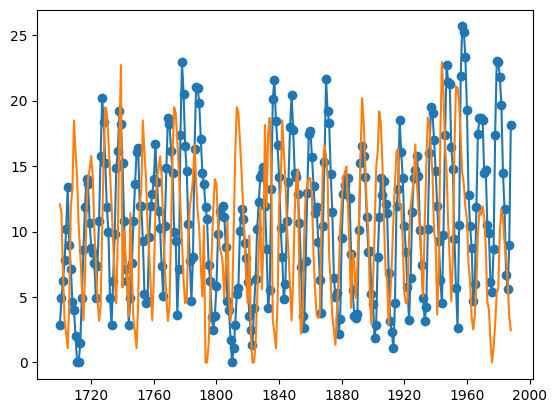

In [26]:
plt.plot(sun.index, sun, 'o-')
plt.plot(sun.index, st_bootstrap_simulations[2])

Now we provide some code to help obtain the maximum order by making estimates from the previous bootstrap.

In [27]:
estimates_from_bootstrap = []
ar_estimates_from_bootstrap = np.zeros((len(st_bootstrap_simulations), ))

for b in range(len(st_bootstrap_simulations)):
    y_bootstrap = st_bootstrap_simulations[b, :]
    ar_bootstrap = AutoReg(y_bootstrap, lags=25)
    estimate_from_bootstrap = ar_bootstrap.fit()
    estimates_from_bootstrap.append(estimate_from_bootstrap)
    ar_estimates_from_bootstrap[b] = estimate_from_bootstrap.params[1]
    # obtain the maximum order

Compare the bootstrap variance for a specific simulation against the original variance.

In [28]:
(bootstrap_simulations[2].var(), sun.var())

(30.116314069490603,
 x    32.056673
 dtype: float64)

Compare the bootstrap variance for all simulations against the original variance.

In [29]:
(bootstrap_simulations.var(), sun.var())

(31.95422158770497,
 x    32.056673
 dtype: float64)

Compare the bootstrap mean for all simulations against the original mean.

In [30]:
(bootstrap_simulations.mean(), sun.mean())

(10.902343379799987,
 x    10.903807
 dtype: float64)